# Задание

На основе анонимизированных данных цифрового следа обучающихся в электронном обучающем курсе проверить гипотезу о наличии связи между активными действиями в электронном курсе и просмотрами. При наличии связи провести регрессионный анализ и подобрать оптимальный вид и параметры функциональной зависимости между переменными Активные действия и Просмотры. Сделать вывод.

Под **просмотрами** считать следующие названия событий: *['Модуль курса просмотрен', 'HotPot attempt reviewed', 'Страница вики просмотрена', 'Показана карта страниц Вики', 'Версия страницы вики просмотрена', 'Комментарии просмотрены',
'Запись просмотрена', 'Отзыв просмотрен', 'Страница состояния представленного ответа просмотрена', 'Глава просмотрена',
'Содержимое страницы просмотрено', 'Вопрос просмотрен', 'Ответ на задание типа «Эссе» просмотрен', 'Отчет просмотрен',
'Работа просмотрена', 'Попытка теста просмотрена', 'Завершенная попытка теста просмотрена', 'Сводка попытки теста просмотрена', 'Тема просмотрена', 'Отчет по пользователю просмотрен', 'Сессии просмотрены']*

Под **активными действиями** считать следующие названия событий: *['Ответ на анкету отправлен', 'Запись создана', 'Запись обновлена', 'Комментарий создан', 'Страница вики создана', 'Страница вики обновлена', 'Комментарий создан', 'Категория создана', 'Категория обновлена', 'Комментарий создан', 'Запись создана', 'Запись обновлена', 'Работа представлена.', 'Представленный ответ обновлен.', 'Комментарий создан', 'Дан ответ на вопрос', 'Лекция закончена', 'Ответ представлен', 'Ответ на опрос добавлен', 'Sco запущен', 'Посещаемость отмечена студентом', 'Работа оценена', 'Работа переоценена', 'Представление работы создано', 'Работа была загружена', 'Работа обновлена', 'Попытка теста завершена и отправлена на оценку', 'Тема создана', 'Сообщение создано', 'Отправлено сообщение']*

**Алгоритм действий:**
1. Считать данные.
2. Исключить данные до начала (до 01.09.2023) и после окончания (до 15.01.2024) осеннего семестра.
3. Агрегировать данные для каждого пользователя по количеству активных действий и просмотров в течение осеннего семестра.
4. Проверить гипотезу независимости критерием хи-квадрат Пирсона (учесть замечание по использованию критерия: $\nu_{ij}>5$).
5. Сделать вывод.
6. При наличии статистически значимой зависимости между количеством активных действий и просмотров, провести регрессионный анализ:
    - вычислить выборочный коэффициент корреляции Пирсона между количеством активных действий и просмотров, проверить его статистическую значимость, сделать вывод о возможности приближения зависимости между количеством активных действий и просмотров линейной функцией;
    - построить линейную регрессию количества активных действий от просмотров, оценить статистическую значимость коэффициентов уравнения линейной регрессии и значимость всего уравнения в целом;
    - проверить выполнение условия адекватности каждой из полученных моделей регрессии (нормальность распределения регрессионных остатков), построив Q-Q график;
    - выбрать еще 2-3 функциональные формы (квадратическая, логарифмическая, экспоненциальная, обратная и т.д.) зависимости количества активных действий от просмотров, оценить коэффициенты для каждого вида зависимости,  проверить выполнение условия адекватности моделей;
    - выбрать оптимальную модель на основании коэффициента детерминации;
    - с помощью оптимальной модели найти прогноз количества активных действий в курсе, произвольным образом задав для него значение просмотров.
7. Сделать выводы.

In [39]:
views = ['Модуль курса просмотрен', 'HotPot attempt reviewed', 'Страница вики просмотрена', 'Показана карта страниц Вики', 'Версия страницы вики просмотрена', 'Комментарии просмотрены',
'Запись просмотрена', 'Отзыв просмотрен', 'Страница состояния представленного ответа просмотрена', 'Глава просмотрена',
'Содержимое страницы просмотрено', 'Вопрос просмотрен', 'Ответ на задание типа «Эссе» просмотрен', 'Отчет просмотрен',
'Работа просмотрена', 'Попытка теста просмотрена', 'Завершенная попытка теста просмотрена', 'Сводка попытки теста просмотрена', 'Тема просмотрена', 'Отчет по пользователю просмотрен', 'Сессии просмотрены']
active = ['Ответ на анкету отправлен', 'Запись создана', 'Запись обновлена', 'Комментарий создан', 'Страница вики создана', 'Страница вики обновлена', 'Комментарий создан', 'Категория создана', 'Категория обновлена', 'Комментарий создан', 'Запись создана', 'Запись обновлена', 'Работа представлена.', 'Представленный ответ обновлен.', 'Комментарий создан', 'Дан ответ на вопрос', 'Лекция закончена', 'Ответ представлен', 'Ответ на опрос добавлен', 'Sco запущен', 'Посещаемость отмечена студентом', 'Работа оценена', 'Работа переоценена', 'Представление работы создано', 'Работа была загружена', 'Работа обновлена', 'Попытка теста завершена и отправлена на оценку', 'Тема создана', 'Сообщение создано', 'Отправлено сообщение']

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pingouin as pg
from scipy.stats import chi2_contingency, pearsonr, boxcox
import statsmodels.api as sm

In [41]:
df = pd.read_csv('df_var_10.csv')
df["Время"] = pd.to_datetime(df["Время"], format="%Y-%m-%d %H:%M:%S")

In [42]:
# 2. Исключить данные до 01.09.2023 и после 15.01.2024
start_date = pd.to_datetime('2023-09-01')
end_date = pd.to_datetime('2024-07-15')
df_filtered = df[(df['Время'] >= start_date) & (df['Время'] <= end_date)]
print(f'Размер отфильтрованного датасета: {df_filtered.shape}')

Размер отфильтрованного датасета: (99264, 7)


In [43]:
# 3. Агрегировать данные по пользователям
views_count = df_filtered[df_filtered['Название события'].isin(views)].groupby('Полное имя пользователя').size().reset_index(name='Просмотры')
active_count = df_filtered[df_filtered['Название события'].isin(active)].groupby('Полное имя пользователя').size().reset_index(name='Активные действия')
df_agg = pd.merge(views_count, active_count, on='Полное имя пользователя', how='outer').fillna(0)
df_agg['Просмотры'] = df_agg['Просмотры'].astype(int)
df_agg['Активные действия'] = df_agg['Активные действия'].astype(int)
df_agg_original = df_agg.copy()

In [44]:
df_agg.info

<bound method DataFrame.info of               Полное имя пользователя  Просмотры  Активные действия
0    0013cbbe04f4ef7e3b68427130879265        221                 51
1    005b103b8dab7a44c8fa0032dd3ce71e        163                 20
2    009811d0356ea306907acb74f86132b4        143                 39
3    009844f1c773a4576914819aeb9aadc3        472                  0
4    00c8ab9c7d42d289a27de525176419bf         50                  1
..                                ...        ...                ...
573  fe4e73969131a10b85e18a41e1b062dc         81                  2
574  fe4eb5a2ceedbea3aa67eb7d055cfb69        214                 49
575  ff6830603cc467816731f20b43481f51         42                  1
576  ffdf6968c44c0efa0ccbe648ef582d0b        361                 19
577  ffe967f2ebab6f6fe1d200905ee31795          5                  0

[578 rows x 3 columns]>

Выбросы по условию: 0
Выбросы по IQR: 108


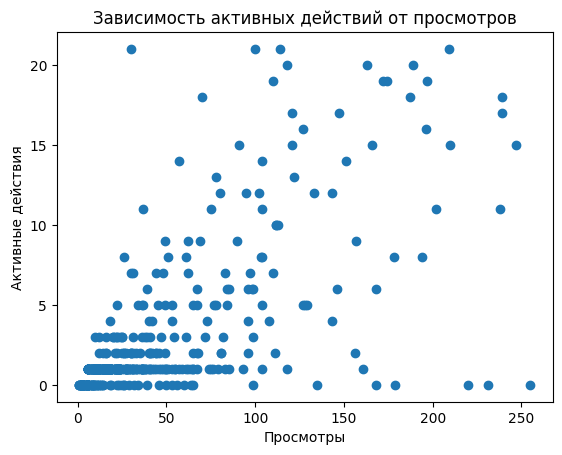

In [45]:
Q1_views = df_agg['Просмотры'].quantile(0.25)
Q3_views = df_agg['Просмотры'].quantile(0.75)
IQR_views = Q3_views - Q1_views
lower_bound_views = Q1_views - 1.5 * IQR_views
upper_bound_views = Q3_views + 1.5 * IQR_views
Q1_actions = df_agg['Активные действия'].quantile(0.25)
Q3_actions = df_agg['Активные действия'].quantile(0.75)
IQR_actions = Q3_actions - Q1_actions
lower_bound_actions = Q1_actions - 1.5 * IQR_actions
upper_bound_actions = Q3_actions + 1.5 * IQR_actions
iqr_outliers = ((df_agg['Просмотры'] < lower_bound_views) |
                (df_agg['Просмотры'] > upper_bound_views) |
                (df_agg['Активные действия'] < lower_bound_actions) |
                (df_agg['Активные действия'] > upper_bound_actions)).sum()

print(f"Выбросы по IQR: {iqr_outliers}")

df_agg = df_agg[
    (df_agg['Просмотры'] >= lower_bound_views) &
    (df_agg['Просмотры'] <= upper_bound_views) &
    (df_agg['Активные действия'] >= lower_bound_actions) &
    (df_agg['Активные действия'] <= upper_bound_actions)
].copy()

plt.scatter(df_agg['Просмотры'], df_agg['Активные действия'])
plt.xlabel('Просмотры')
plt.ylabel('Активные действия')
plt.title('Зависимость активных действий от просмотров')
plt.show()

In [46]:
# 4. Проверить гипотезу независимости критерием хи-квадрат
from scipy.stats import chi2_contingency

views_edges = [0,100, 150, np.inf] 
active_edges = [0,10, np.inf]   

df_agg['views_bin'] = pd.cut(df_agg['Просмотры'], bins=views_edges)
df_agg['active_bin'] = pd.cut(df_agg['Активные действия'], bins=active_edges)

contingency = pd.crosstab(df_agg['views_bin'], df_agg['active_bin'])

if (contingency.values < 5).any():
    print("Внимание: есть ячейки с частотой < 5")
else:
    print("Условие выполнено: все ячейки ≥ 5")

chi2, p, dof, expected = chi2_contingency(contingency)
print(f'Chi2: {chi2}')
print(f'p-value: {p}')
print(f'DOF: {dof}')
print('Ожидаемые частоты:\n', expected)

if p<=0.05:
    print("Гипотеза о независимости отверграется")
else:
    print("Гипотеза о независимости не отверграется")
contingency

Условие выполнено: все ячейки ≥ 5
Chi2: 147.1990021738585
p-value: 1.0867829268431764e-32
DOF: 2
Ожидаемые частоты:
 [[290.304  33.696]
 [ 25.984   3.016]
 [ 19.712   2.288]]
Гипотеза о независимости отверграется


active_bin,"(0.0, 10.0]","(10.0, inf]"
views_bin,,
"(0.0, 100.0]",314,10
"(100.0, 150.0]",16,13
"(150.0, inf]",6,16


In [47]:
corr, p_corr = pearsonr(df_agg['Просмотры'], df_agg['Активные действия'])
print(f'Коэффициент корреляции Пирсона: {corr}')
print(f'p-value: {p_corr}')

if p_corr < 0.05:
    print('Корреляция статистически значима.')
else:
    print('Корреляция не значима.')

Коэффициент корреляции Пирсона: 0.6837809315901487
p-value: 4.771493557559148e-66
Корреляция статистически значима.


Оптимальное lambda для Box-Cox: -0.5732436642685893
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.311
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     211.6
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           8.20e-40
Time:                        12:22:22   Log-Likelihood:                -167.15
No. Observations:                 470   AIC:                             338.3
Df Residuals:                     468   BIC:                             346.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------


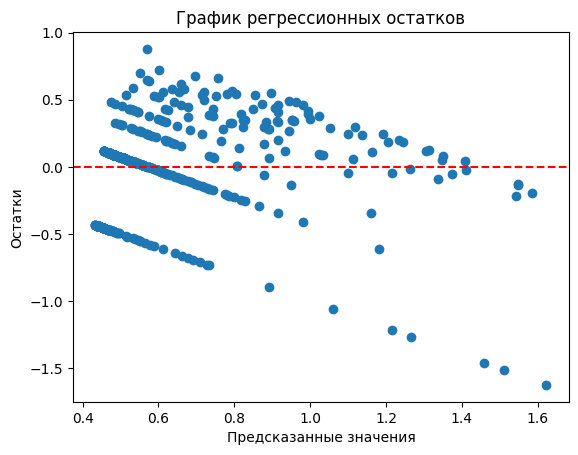

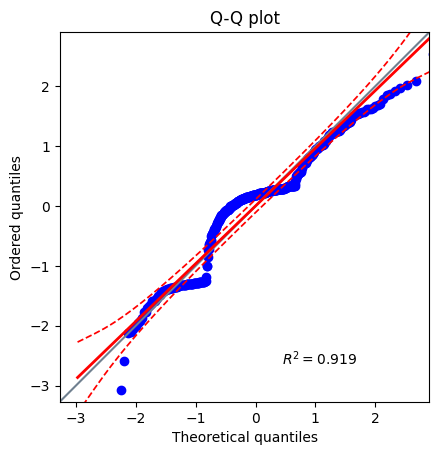

In [48]:
y = df_agg['Активные действия'] + 1
y_boxcox, lambda_boxcox = boxcox(y)
print(f'Оптимальное lambda для Box-Cox: {lambda_boxcox}')

X_lin = sm.add_constant(df_agg['Просмотры'])
model_lin = sm.OLS(y_boxcox, X_lin).fit()
print(model_lin.summary())

plt.scatter(model_lin.fittedvalues, model_lin.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков')
plt.axhline(0, color='red', linestyle='--')
plt.show()

pg.qqplot(model_lin.resid)
plt.title('Q-Q plot')
plt.show()

Prob (F-statistic):           9.44e-50 << 0.05 => модель значима

Для обои коэффициентов модели p_value<< 0 => коэффициенты значимы

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.425
Model:                            OLS   Adj. R-squared:                  0.422
Method:                 Least Squares   F-statistic:                     172.5
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           7.93e-57
Time:                        12:22:23   Log-Likelihood:                -124.80
No. Observations:                 470   AIC:                             255.6
Df Residuals:                     467   BIC:                             268.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2770      0.025     11.082      0.0

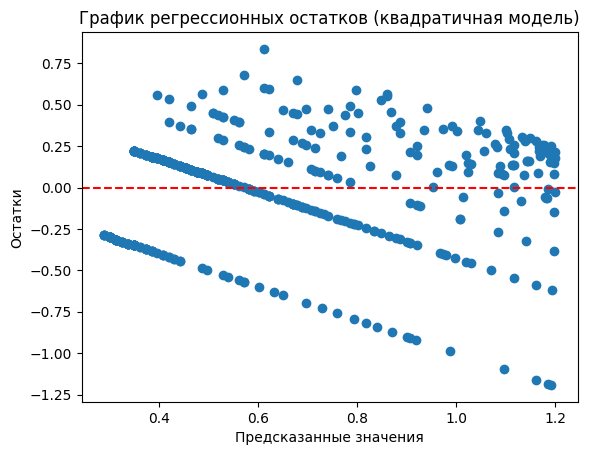

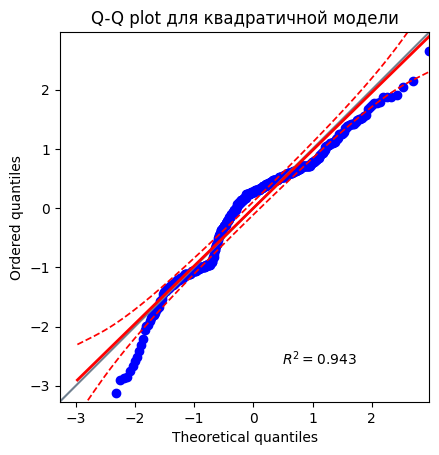

In [49]:
# Квадратичная модель
df_agg['views_sq'] = df_agg['Просмотры'] ** 2
X_quad = sm.add_constant(df_agg[['Просмотры', 'views_sq']])
model_quad = sm.OLS(y_boxcox, X_quad).fit()
print(model_quad.summary())

# График остатков
plt.scatter(model_quad.fittedvalues, model_quad.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков (квадратичная модель)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Q-Q plot
pg.qqplot(model_quad.resid, dist='norm', confidence=0.95)
plt.title('Q-Q plot для квадратичной модели')
plt.show()

Prob (F-statistic) << 0.05 => модель значима

Для всех коэффициентов модели p_value<0.05 => коэффициенты значимы

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.461
Model:                            OLS   Adj. R-squared:                  0.459
Method:                 Least Squares   F-statistic:                     200.0
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           1.82e-63
Time:                        12:22:23   Log-Likelihood:                -109.41
No. Observations:                 470   AIC:                             224.8
Df Residuals:                     467   BIC:                             237.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.3020      0.067     -4.522      0.0

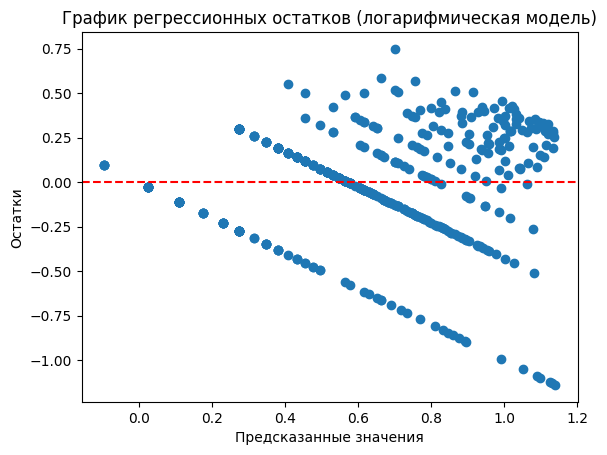

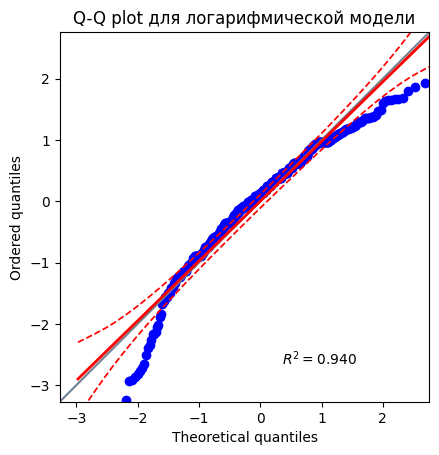

In [50]:
# Логарифмическая
df_agg['views_log'] = np.log(df_agg['Просмотры'] + 1)
X_log = sm.add_constant(df_agg[['views_log','Просмотры']])
model_log = sm.OLS(y_boxcox, X_log).fit()
print(model_log.summary())

# График остатков
plt.scatter(model_log.fittedvalues, model_log.resid)
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки')
plt.title('График регрессионных остатков (логарифмическая модель)')
plt.axhline(0, color='red', linestyle='--')
plt.show()

# Q-Q plot
pg.qqplot(model_log.resid, dist='norm', confidence=0.95)
plt.title('Q-Q plot для логарифмической модели')
plt.show()

Prob (F-statistic) << 0.05 => модель значима.

Переменная "Просмотры" оказывается незначима для модели, возможно views_log и константа уже вносят вклад, от которого сложно отличить "Просмотры".

In [51]:
models = {
    'Линейная': model_lin,
    'Квадратичная': model_quad,
    'Логарифмическая': model_log
}
best_model_name = max(models, key=lambda name: models[name].rsquared)
best_model = models[best_model_name]
best_model_name

'Логарифмическая'

In [91]:
from scipy.special import inv_boxcox
prosmotry_input = 10

X_new = pd.DataFrame({
    'const': [1],
    'views_log': np.log(prosmotry_input+1),
    'Просмотры': [prosmotry_input]
})

# предсказание в преобразованной шкале 
y_pred_boxcox = best_model.predict(X_new)[0]

# Обратное преобразование BoxCox 
from scipy.special import inv_boxcox
y_pred = inv_boxcox(y_pred_boxcox, lambda_boxcox) - 1  # вычитаем 1, т.к. мы добавляли 1 ранее

print(f"Прогноз количества активных действий при {prosmotry_input} просмотрах: {np.round(y_pred, 2)}")

Прогноз количества активных действий при 10 просмотрах: 0.59


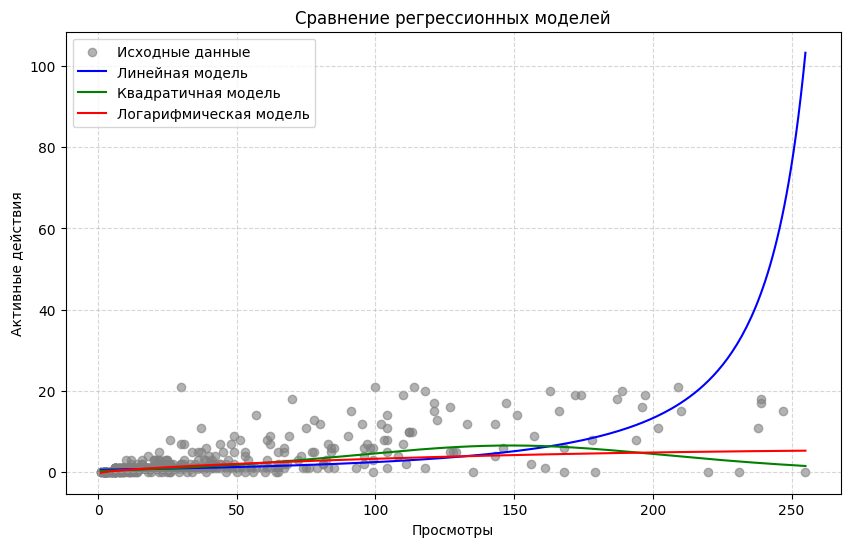

In [53]:
x_vals = df_agg['Просмотры'].values
y_vals = df_agg['Активные действия'].values

y_orig = inv_boxcox(y_boxcox, lambda_boxcox) - 1

x_grid = np.linspace(x_vals.min(), x_vals.max(), 300)


X_lin_grid = sm.add_constant(x_grid)
y_lin_pred_bc = model_lin.predict(X_lin_grid)
y_lin_pred = inv_boxcox(y_lin_pred_bc, lambda_boxcox) - 1


X_quad_grid = sm.add_constant(np.column_stack([x_grid, x_grid**2]))
y_quad_pred_bc = model_quad.predict(X_quad_grid)
y_quad_pred = inv_boxcox(y_quad_pred_bc, lambda_boxcox) - 1


X_log_grid = sm.add_constant(np.column_stack([np.log(x_grid + 1), x_grid]))
y_log_pred_bc = model_log.predict(X_log_grid)
y_log_pred = inv_boxcox(y_log_pred_bc, lambda_boxcox) - 1


plt.figure(figsize=(10, 6))
plt.scatter(x_vals, y_vals, alpha=0.6, label='Исходные данные', color='gray')

plt.plot(x_grid, y_lin_pred, label='Линейная модель', color='blue')
plt.plot(x_grid, y_quad_pred, label='Квадратичная модель', color='green')
plt.plot(x_grid, y_log_pred, label='Логарифмическая модель', color='red')

plt.xlabel('Просмотры')
plt.ylabel('Активные действия')
plt.title('Сравнение регрессионных моделей')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Нулевые значения: 100 из 578 (17.30%)
1 значения: 226 из 578 (39.10%)


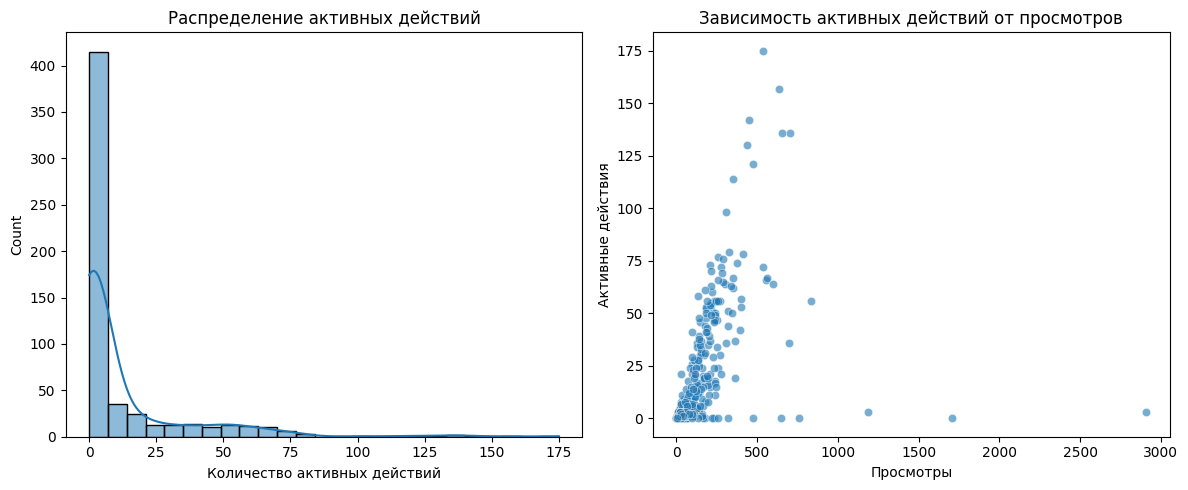

In [54]:
df_agg = df_agg_original.copy()
zero_count = (df_agg['Активные действия'] == 0).sum()
one_count = (df_agg['Активные действия'] == 1).sum()
total_count = len(df_agg)
print(f"Нулевые значения: {zero_count} из {total_count} ({zero_count/total_count:.2%})")
print(f"1 значения: {one_count} из {total_count} ({one_count/total_count:.2%})")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_agg['Активные действия'], bins=25, kde=True)
plt.title('Распределение активных действий')
plt.xlabel('Количество активных действий')

plt.subplot(1, 2, 2)
sns.scatterplot(x='Просмотры', y='Активные действия', data=df_agg, alpha=0.6)
plt.title('Зависимость активных действий от просмотров')
plt.xlabel('Просмотры')
plt.ylabel('Активные действия')
plt.tight_layout()
plt.show()

Несмотря на то, что классические регрессионные модели показали статистическую значимость они показали низкие метрики R^2 и Q-Q графики для моделей показывают явное отколнение регресионных остатков от нормального распределения. Учитывая особенности распределения - обилие нулей и единиц построим двухэтапную модель.

# Hurdle

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, mean_squared_error, r2_score, confusion_matrix, ConfusionMatrixDisplay

Нулевые значения: 100 из 578 (17.30%)
Значения, равные 1: 226 из 578 (39.10%)

Исходное разделение данных:
  - Низкая активность (<=1): 326 наблюдений
  - Высокая активность (>1): 252 наблюдений

Очистка выбросов для низкой активности (<=1):
  - Исходное количество: 326
  - Удалено выбросов: 31 (9.5%)
  - Границы просмотров: [0.00, 59.50]
  - Осталось: 295

Очистка выбросов для высокой активности (>1):
  - Исходное количество после фильтрации просмотров: 239
  - Удалено выбросов по активности: 4 (1.7%)
  - Границы просмотров: [0.00, 458.12]
  - Границы активности: [1.00, 87.75]
  - Осталось: 235

Итоги очистки:
  - Низкая активность после очистки: 295
  - Высокая активность после очистки: 235
  - Общий объем очищенных данных: 530 (91.7% от исходных)
Optimization terminated successfully.
         Current function value: 0.263666
         Iterations 9

Результаты логистической регрессии на очищенных данных:
                           Logit Regression Results                           
De

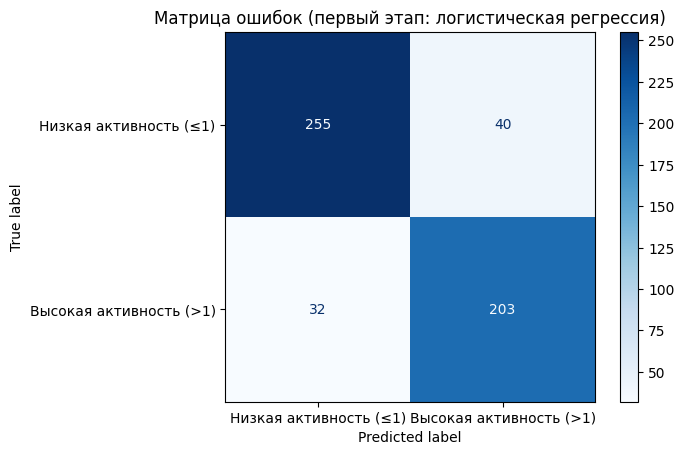


Оптимальное lambda для Box-Cox (только для значений >1): -0.0389

Результаты квадратичной регрессии:
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.716
Model:                            OLS   Adj. R-squared:                  0.714
Method:                 Least Squares   F-statistic:                     293.0
Date:                Fri, 12 Dec 2025   Prob (F-statistic):           3.29e-64
Time:                        14:08:49   Log-Likelihood:                -176.82
No. Observations:                 235   AIC:                             359.6
Df Residuals:                     232   BIC:                             370.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

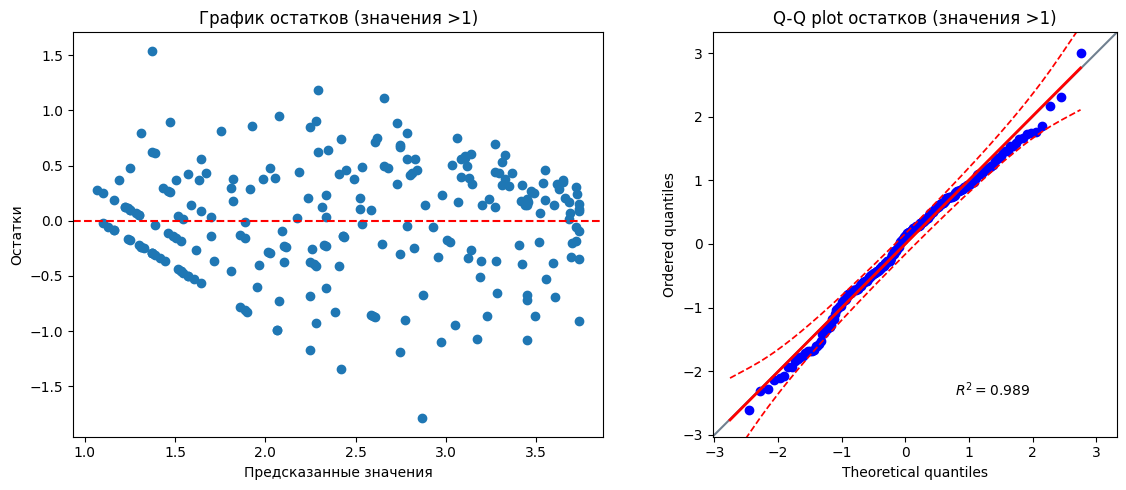


Прогноз для 10 просмотров:
Вероятность активности >1: 0.0573
Прогнозируемое количество активных действий: 1.00
(Порог вероятности: 0.3)
Аналог accuracy для Hurdle Model: 0.3472
Коэффициент детерминации Hurdle Model: 0.7526


In [85]:
df_agg = df_agg_original.copy()
threshold = 0.3
# распределение нулей и единиц
zero_count = (df_agg['Активные действия'] == 0).sum()
one_count = (df_agg['Активные действия'] == 1).sum()
total_count = len(df_agg)
print(f"Нулевые значения: {zero_count} из {total_count} ({zero_count/total_count:.2%})")
print(f"Значения, равные 1: {one_count} из {total_count} ({one_count/total_count:.2%})")

low_activity = df_agg[df_agg['Активные действия'] <= 1].copy()
high_activity = df_agg[df_agg['Активные действия'] > 1].copy()

print(f"\nИсходное разделение данных:")
print(f"  - Низкая активность (<=1): {len(low_activity)} наблюдений")
print(f"  - Высокая активность (>1): {len(high_activity)} наблюдений")

# Очистка для группы с низкой активностью
if not low_activity.empty:
    Q1_low_views = low_activity['Просмотры'].quantile(0.25)
    Q3_low_views = low_activity['Просмотры'].quantile(0.75)
    IQR_low_views = Q3_low_views - Q1_low_views
    
    lower_bound_low_views = max(0, Q1_low_views - 1.5 * IQR_low_views)
    upper_bound_low_views = Q3_low_views + 1.5 * IQR_low_views
    
    pre_filter_low = len(low_activity)
    low_activity_cleaned = low_activity[
        (low_activity['Просмотры'] >= lower_bound_low_views) &
        (low_activity['Просмотры'] <= upper_bound_low_views)
    ].copy()
    
    post_filter_low = len(low_activity_cleaned)
    outliers_low_removed = pre_filter_low - post_filter_low
    
    print(f"\nОчистка выбросов для низкой активности (<=1):")
    print(f"  - Исходное количество: {pre_filter_low}")
    print(f"  - Удалено выбросов: {outliers_low_removed} ({outliers_low_removed/pre_filter_low:.1%})")
    print(f"  - Границы просмотров: [{lower_bound_low_views:.2f}, {upper_bound_low_views:.2f}]")
    print(f"  - Осталось: {post_filter_low}")
else:
    low_activity_cleaned = low_activity.copy()

# Очистка для группы с высокой активностью 
if not high_activity.empty:
    Q1_high_views = high_activity['Просмотры'].quantile(0.25)
    Q3_high_views = high_activity['Просмотры'].quantile(0.75)
    IQR_high_views = Q3_high_views - Q1_high_views
    
    lower_bound_high_views = max(0, Q1_high_views - 1.5 * IQR_high_views)
    upper_bound_high_views = Q3_high_views + 1.5 * IQR_high_views
    
    high_activity_temp = high_activity[
        (high_activity['Просмотры'] >= lower_bound_high_views) &
        (high_activity['Просмотры'] <= upper_bound_high_views)
    ].copy()
    
    Q1_high_act = high_activity_temp['Активные действия'].quantile(0.25)
    Q3_high_act = high_activity_temp['Активные действия'].quantile(0.75)
    IQR_high_act = Q3_high_act - Q1_high_act
    
    lower_bound_high_act = max(1, Q1_high_act - 1.5 * IQR_high_act)
    upper_bound_high_act = Q3_high_act + 1.5 * IQR_high_act
    
    pre_filter_high = len(high_activity_temp)
    high_activity_cleaned = high_activity_temp[
        (high_activity_temp['Активные действия'] >= lower_bound_high_act) &
        (high_activity_temp['Активные действия'] <= upper_bound_high_act)
    ].copy()
    
    post_filter_high = len(high_activity_cleaned)
    outliers_high_removed = pre_filter_high - post_filter_high
    
    print(f"\nОчистка выбросов для высокой активности (>1):")
    print(f"  - Исходное количество после фильтрации просмотров: {pre_filter_high}")
    print(f"  - Удалено выбросов по активности: {outliers_high_removed} ({outliers_high_removed/pre_filter_high:.1%})")
    print(f"  - Границы просмотров: [{lower_bound_high_views:.2f}, {upper_bound_high_views:.2f}]")
    print(f"  - Границы активности: [{lower_bound_high_act:.2f}, {upper_bound_high_act:.2f}]")
    print(f"  - Осталось: {post_filter_high}")
else:
    high_activity_cleaned = high_activity.copy()

df_cleaned = pd.concat([low_activity_cleaned, high_activity_cleaned]).sort_index()
total_cleaned = len(df_cleaned)

print(f"\nИтоги очистки:")
print(f"  - Низкая активность после очистки: {len(low_activity_cleaned)}")
print(f"  - Высокая активность после очистки: {len(high_activity_cleaned)}")
print(f"  - Общий объем очищенных данных: {total_cleaned} ({total_cleaned/len(df_agg):.1%} от исходных)")

# Hurdle Model состоит из двух частей:
# 1. Бинарная модель для разделения на две группы: <=1 и >1
# 2. Модель для значений >1 (квадратичная регрессия)

## Часть 1: Бинарная модель (логистическая регрессия)
# Создаем бинарную переменную на очищенных данных
df_cleaned['is_high_activity'] = (df_cleaned['Активные действия'] > 1).astype(int)

X_binary = sm.add_constant(df_cleaned[['Просмотры']])
binary_model = sm.Logit(df_cleaned['is_high_activity'], X_binary).fit()

print("\nРезультаты логистической регрессии на очищенных данных:")
print(binary_model.summary())


y_true_bin = df_cleaned['is_high_activity']
y_pred_bin = (binary_model.predict(X_binary) > threshold).astype(int)

accuracy_bin = accuracy_score(y_true_bin, y_pred_bin)
precision_bin = precision_score(y_true_bin, y_pred_bin)
recall_bin = recall_score(y_true_bin, y_pred_bin)

print("\nМетрики логистической регрессии:")
print(f"Accuracy: {accuracy_bin:.4f}")
print(f"Precision: {precision_bin:.4f}")
print(f"Recall: {recall_bin:.4f}")

cm = confusion_matrix(y_true_bin, y_pred_bin)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Низкая активность (≤1)', 'Высокая активность (>1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Матрица ошибок (первый этап: логистическая регрессия)")
plt.show()

## Часть 2: Квадратичная регрессия для значений >1
high_activity_data = df_cleaned[df_cleaned['Активные действия'] > 1].copy()
high_activity_data['views_sq'] = high_activity_data['Просмотры'] ** 2

if len(high_activity_data) == 0:
    print("Нет данных с активными действиями > 1 для построения второй части модели")
else:
    y_high = high_activity_data['Активные действия'] + 1
    y_high_boxcox, lambda_high = boxcox(y_high)
    print(f"\nОптимальное lambda для Box-Cox (только для значений >1): {lambda_high:.4f}")

    X_quad_high = sm.add_constant(high_activity_data[['Просмотры', 'views_sq']])
    quad_model_high = sm.OLS(y_high_boxcox, X_quad_high).fit()

    print("\nРезультаты квадратичной регрессии:")
    print(quad_model_high.summary())

    pred_boxcox = quad_model_high.predict(X_quad_high)
    pred_high = inv_boxcox(pred_boxcox, lambda_high) - 1
    
    y_true_high = high_activity_data['Активные действия']
    mae_high = mean_absolute_error(y_true_high, pred_high)
    rmse_high = np.sqrt(mean_squared_error(y_true_high, pred_high))
    r2_high = r2_score(y_true_high, pred_high)

    print("\nМетрики квадратичной регрессии:")
    print(f"MAE: {mae_high:.4f}")
    print(f"RMSE: {rmse_high:.4f}")
    print(f"R^2: {r2_high:.4f}")
    
    ## Оценка адекватности второй части модели
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(quad_model_high.fittedvalues, quad_model_high.resid)
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('График остатков (значения >1)')
    plt.axhline(0, color='red', linestyle='--')

    plt.subplot(1, 2, 2)
    pg.qqplot(quad_model_high.resid, dist='norm', confidence=0.95)
    plt.title('Q-Q plot остатков (значения >1)')

    plt.tight_layout()
    plt.show()

    # Комбинирование результатов и прогнозирование
    # Предсказание вероятности попадания в группу >1
    X_binary_full = sm.add_constant(df_cleaned[['Просмотры']])
    df_cleaned['prob_high'] = binary_model.predict(X_binary_full)

    # Предсказание значений для группы >1
    df_cleaned['pred_high'] = np.nan
    X_quad_all = pd.DataFrame({
        'const': 1,
        'Просмотры': df_cleaned['Просмотры'],
        'views_sq': df_cleaned['Просмотры'] ** 2
    })[['const', 'Просмотры', 'views_sq']]

    mask_high = df_cleaned['Активные действия'] > 1
    if mask_high.any():
        pred_boxcox = quad_model_high.predict(X_quad_all.loc[mask_high])
        pred_high = inv_boxcox(pred_boxcox, lambda_high) - 1 
        df_cleaned.loc[mask_high, 'pred_high'] = pred_high

    # Комбинируем результаты
    df_cleaned['hurdle_pred'] = np.where(df_cleaned['prob_high'] > threshold, 
                                        np.maximum(1.0, df_cleaned['pred_high']),
                                        1)

    ## Оценка качества Hurdle Model 
    df_valid = df_cleaned.dropna(subset=['hurdle_pred'])
    
    ss_res = np.sum((df_valid['Активные действия'] - df_valid['hurdle_pred'])**2)
    ss_tot = np.sum((df_valid['Активные действия'] - df_valid['Активные действия'].mean())**2)
    r2_hurdle = 1 - (ss_res / ss_tot) if ss_tot != 0 else np.nan


## Прогноз для конкретного значения
example_views = 10

X_new_binary = pd.DataFrame({'Просмотры': [example_views]})
X_new_binary.insert(0, 'const', 1.0)
prob_high_new = binary_model.predict(X_new_binary)[0]

X_new_quad = pd.DataFrame({
    'const': [1.0],
    'Просмотры': [example_views],
    'views_sq': [example_views**2]
})
pred_high_new_boxcox = quad_model_high.predict(X_new_quad)[0]
pred_high_new = inv_boxcox(pred_high_new_boxcox, lambda_high) - 1

if prob_high_new > threshold:
    final_pred = pred_high_new
else:
    final_pred = 1
    
print(f"\nПрогноз для {example_views} просмотров:")
print(f"Вероятность активности >1: {prob_high_new:.4f}")
print(f"Прогнозируемое количество активных действий: {final_pred:.2f}")
print(f"(Порог вероятности: {threshold})")

df_cleaned['abs_error'] = np.abs(df_cleaned['Активные действия'] - df_cleaned['hurdle_pred'])
overall_accuracy = (df_cleaned['abs_error']<0.5).mean()

print(f"Аналог accuracy для Hurdle Model: {overall_accuracy:.4f}")
print(f"Коэффициент детерминации Hurdle Model: {r2_hurdle:.4f}")

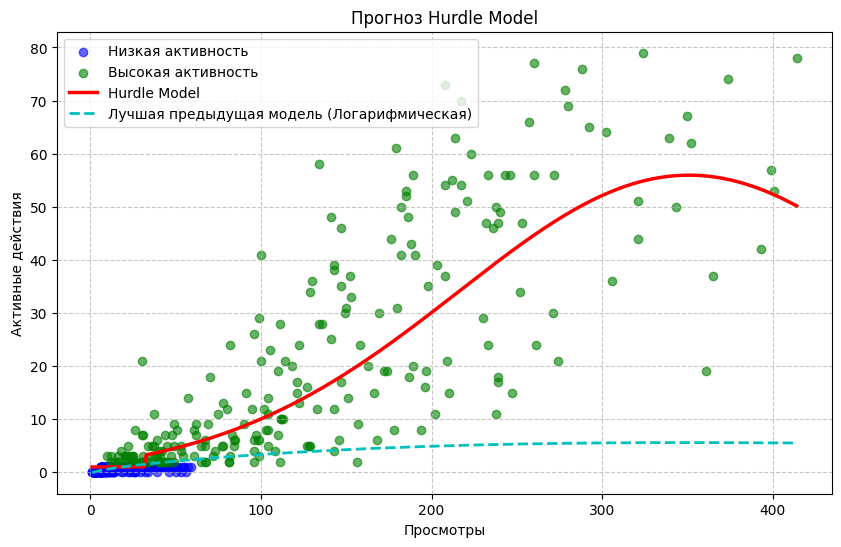

In [92]:
plt.figure(figsize=(10, 6))

plt.scatter(low_activity_cleaned['Просмотры'], 
            low_activity_cleaned['Активные действия'],
            alpha=0.6, label='Низкая активность', color='blue')

plt.scatter(high_activity_cleaned['Просмотры'], 
            high_activity_cleaned['Активные действия'],
            alpha=0.6, label='Высокая активность', color='green')

# Предсказания Hurdle
x_grid = np.linspace(df_cleaned['Просмотры'].min(), df_cleaned['Просмотры'].max(), 300)
X_grid_binary = sm.add_constant(pd.DataFrame({'Просмотры': x_grid}))
prob_high_grid = binary_model.predict(X_grid_binary)

X_grid_quad = pd.DataFrame({
    'const': 1,
    'Просмотры': x_grid,
    'views_sq': x_grid ** 2
})[['const', 'Просмотры', 'views_sq']]

pred_high_grid_boxcox = quad_model_high.predict(X_grid_quad)
pred_high_grid = inv_boxcox(pred_high_grid_boxcox, lambda_high) - 1

hurdle_pred_grid = np.where(prob_high_grid > threshold, pred_high_grid, 1)
plt.plot(x_grid, hurdle_pred_grid, 'r-', linewidth=2.5, label='Hurdle Model')

if best_model_name == 'Квадратичная':
    y_best_pred = inv_boxcox(model_quad.predict(X_quad_grid), lambda_boxcox) - 1
    plt.plot(x_grid, y_best_pred, 'm--', linewidth=2, label='Лучшая предыдущая модель (Квадратичная)')
    
elif best_model_name == 'Логарифмическая':
    X_log_grid = pd.DataFrame({
        'const': 1,
        'views_log': np.log(x_grid + 1),
        'Просмотры': x_grid
    })[['const', 'views_log', 'Просмотры']]
    
    y_log_pred_boxcox = model_log.predict(X_log_grid)
    y_best_pred = inv_boxcox(y_log_pred_boxcox, lambda_boxcox) - 1
    
    plt.plot(x_grid, y_best_pred, 'c--', linewidth=2, label='Лучшая предыдущая модель (Логарифмическая)')

plt.xlabel('Просмотры')
plt.ylabel('Активные действия')
plt.title('Прогноз Hurdle Model')
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Подробное объяснение ячейки с построением Hurdle-модели

## Суть подхода: Двухэтапное моделирование (Hurdle Model)

### 1. **Инициализация и анализ распределения данных**
```python
df_agg = df_agg_original.copy()
threshold = 0.3
```
- **Создается копия исходных данных** для сохранения оригинального датасета
- **Устанавливается порог 0.3** для бинарной классификации (вероятность > 0.3 означает "высокая активность")

### 2. **Диагностика проблемы распределения**
```python
zero_count = (df_agg['Активные действия'] == 0).sum()
one_count = (df_agg['Активные действия'] == 1).sum()
```
- **Подсчет нулей и единиц**: анализ показывает, что данные имеют "тяжелый хвост" с избытком нулевых и минимальных значений
- **Содержательная интерпретация**: 
  - 0 активных действий = студент вообще не участвовал
  - 1 активное действие = минимальное участие
  - \>1 активных действий = активное вовлечение

### 3. **Разделение данных на группы**
```python
low_activity = df_agg[df_agg['Активные действия'] <= 1].copy()
high_activity = df_agg[df_agg['Активные действия'] > 1].copy()
```
- **Группа низкой активности (≤1)**: качественно отличается - это "пассивные" или "минимально активные" студенты
- **Группа высокой активности (>1)**: "активно вовлеченные" студенты

### 4. **Раздельная очистка выбросов**
Разные группы имеют разные распределения, поэтому выбросы удаляются раздельно.

#### Для низкой активности:
```python
Q1_low_views = low_activity['Просмотры'].quantile(0.25)
Q3_low_views = low_activity['Просмотры'].quantile(0.75)
IQR_low_views = Q3_low_views - Q1_low_views
```
- **Анализируются только просмотры**, так как активность ограничена (0 или 1)
- **Метод IQR** (межквартильный размах) для определения границ выбросов
- **Формула**: значения за пределами [Q1 - 1.5×IQR, Q3 + 1.5×IQR] считаются выбросами

#### Для высокой активности:
```python
Q1_high_views = high_activity['Просмотры'].quantile(0.25)
Q3_high_views = high_activity['Просмотры'].quantile(0.75)
IQR_high_views = Q3_high_views - Q1_high_views
```
- **Двухэтапная очистка**:
  1. Сначала по просмотрам
  2. Затем по активным действиям

### 5. **Построение Hurdle-модели**

#### Этап 1: Бинарная классификация
```python
df_cleaned['is_high_activity'] = (df_cleaned['Активные действия'] > 1).astype(int)
X_binary = sm.add_constant(df_cleaned[['Просмотры']])
binary_model = sm.Logit(df_cleaned['is_high_activity'], X_binary).fit()
```
- **Логистическая регрессия** предсказывает вероятность принадлежности к группе высокой активности
- **Вход**: количество просмотров
- **Выход**: вероятность P(активность > 1 | просмотры)

#### Этап 2: Регрессия для активных студентов
```python
high_activity_data = df_cleaned[df_cleaned['Активные действия'] > 1].copy()
high_activity_data['views_sq'] = high_activity_data['Просмотры'] ** 2
y_high = high_activity_data['Активные действия'] + 1
y_high_boxcox, lambda_high = boxcox(y_high)
quad_model_high = sm.OLS(y_high_boxcox, X_quad_high).fit()
```
- **Квадратичная регрессия с преобразованием Box-Cox**
- **Моделируется только подмножество** студентов с активностью > 1
- **Box-Cox преобразование** улучшает нормальность распределения
```python
df_cleaned['prob_high'] = binary_model.predict(X_binary_full) '
```
### 6. **Комбинирование результатов**
```python
df_cleaned['hurdle_pred'] = np.where(df_cleaned['prob_high'] > threshold, 
                                     np.maximum(1.0, df_cleaned['pred_high']),
                                     1)
```
- **Правило принятия решения**:
  - Если вероятность высокой активности > threshold (0.3), используем предсказание квадратичной модели
  - Иначе - предсказываем 1 (минимальная активность)

### 7. **Оценка качества модели**
```python
accuracy_bin = accuracy_score(y_true_bin, y_pred_bin)
precision_bin = precision_score(y_true_bin, y_pred_bin)
recall_bin = recall_score(y_true_bin, y_pred_bin)

mae_high = mean_absolute_error(y_true_high, pred_high)
rmse_high = np.sqrt(mean_squared_error(y_true_high, pred_high))
r2_high = r2_score(y_true_high, pred_high)
```
- **Метрики для этапа 1** (классификация): Accuracy, Precision, Recall
- **Метрики для этапа 2** (регрессия): MAE, RMSE, R²
- **Общая оценка**: вычисляется R² для всей Hurdle-модели

### 8. **Прогнозирование на новых данных**
```python
example_views = 10
prob_high_new = binary_model.predict(X_new_binary)[0]
pred_high_new = inv_boxcox(pred_high_new_boxcox, lambda_high) - 1
```
- **Пример для 10 просмотров**:
  1. Сначала оценивается вероятность высокой активности
  2. Если вероятность > 0.3, используется квадратичная модель
  3. Иначе прогноз = 1

### 9. **Визуализация диагностики**
- **Матрица ошибок** для логистической регрессии
- **График остатков** и **Q-Q plot** для квадратичной регрессии

